In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Plotstyle
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

In [201]:
folder = r"D:\projects\Brazilian E-Commerce Public Dataset\data\sampled data\\"

In [202]:
order_level = pd.read_csv(folder + "order_level.csv")
item_level = pd.read_csv(folder + "item_level.csv")

orders_s = pd.read_csv(folder + "orders.csv")
customers_s   = pd.read_csv(folder + "customers.csv")
order_items_s = pd.read_csv(folder + "order_items.csv")
products_s    = pd.read_csv(folder + "products.csv")
sellers_s     = pd.read_csv(folder + "sellers.csv")
print("Loaded")
print("order_level:", order_level.shape, "| item_level:", item_level.shape)


Loaded
order_level: (10000, 23) | item_level: (11383, 22)


\\Missing_value_analysis

In [203]:

def missing_report(df, table_name):
    
    total = len(df)
    miss = df.isnull().sum()                    
    pct  = (miss / total * 100).round(2)         
    report = pd.DataFrame({
        "missing_count": miss,
        "missing_pct": pct
    })

    report = report[report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
    print(f"\n===== {table_name} (total {total:,} rows) =====")
    if report.empty:
        print("No missing values ")
    else:
        print(report)
    return report

miss_order = missing_report(order_level, "order_level")
miss_item  = missing_report(item_level, "item_level")


===== order_level (total 10,000 rows) =====
                               missing_count  missing_pct
order_delivered_customer_date            285         2.85
order_delivered_carrier_date             179         1.79
n_reviews                                 88         0.88
avg_review_score                          88         0.88
geolocation_lat                           35         0.35
geolocation_zip_code_prefix               35         0.35
geolocation_city                          35         0.35
gelocation_lng                            35         0.35
geolocation_state                         35         0.35
order_approved_at                         24         0.24
n_payments_methods                         1         0.01
max_installments                           1         0.01
total_payment_value                        1         0.01
main_payment_type                          1         0.01

===== item_level (total 11,383 rows) =====
                               missing_co

\\Duplicate Analysis

In [204]:
def duplicate_report(df, table_name, key_col=None):
    full_dup = df.duplicated().sum()
    print(f"\n===={table_name} ====")
    print(f"Fully fuplicate rows: {full_dup}")
    if key_col:
        key_dup = df.duplicated(subset=[key_col]).sum()
        print(f"Duplicate '{key_col}':{key_dup}")
    return full_dup

duplicate_report(order_level, "order_level", key_col="order_id")
duplicate_report(item_level, "item_level")
duplicate_report(customers_s, "customers", key_col="customer_id")
    


====order_level ====
Fully fuplicate rows: 0
Duplicate 'order_id':0

====item_level ====
Fully fuplicate rows: 0

====customers ====
Fully fuplicate rows: 0
Duplicate 'customer_id':0


np.int64(0)

\\Check orphans

In [205]:
def check_orphans(child_df, child_key, parent_df, parent_key, label):
    child_keys = set(child_df[child_key].dropna())
    parent_keys = set(parent_df[parent_key])
    orphans = child_keys - parent_keys
    print(f"{label}: {len(orphans)} orphan keys", "YES" if len(orphans)!=0 else "NO")
    return orphans

print("==== Referential Integrity ====")  
check_orphans(orders_s, "customer_id", customers_s, "customer_id",
              "orders.customer_id -> customers")
check_orphans(order_items_s, "order_id", orders_s, "order_id",
              "order_items.order_id -> orders")
check_orphans(order_items_s, "product_id", products_s, "product_id",
              "order_items.product_id -> products")
check_orphans(order_items_s, "seller_id", sellers_s, "seller_id",
              "order_items.seller_is -> sellers")

==== Referential Integrity ====
orders.customer_id -> customers: 0 orphan keys NO
order_items.order_id -> orders: 0 orphan keys NO
order_items.product_id -> products: 0 orphan keys NO
order_items.seller_is -> sellers: 0 orphan keys NO


set()

\\Invalid Value + Consistency Checks

In [206]:
print("==== Invalid Value Checks ====")

neg_price = (item_level["price"] <= 0).sum()
neg_freight = (item_level["freight_value"] < 0).sum()
print(f"Price <= 0     :   {neg_price}")
print(f"Freight < 0    :   {neg_freight}")

Invalid_review = (~order_level["avg_review_score"].between(1,5)).sum() if "avg_review_score" in order_level else 0
print(f"Review out of 1-5: {Invalid_review} (Ignore NaN)")

od = order_level.copy()
od["order_purchase_timestamp"] = pd.to_datetime(od["order_purchase_timestamp"], errors="coerce")
od["order_delivered_customer_date"] = pd.to_datetime(od["order_delivered_customer_date"], errors="coerce")
Invalid_delivery = (od["order_delivered_customer_date"] < od["order_purchase_timestamp"]).sum()
print(f"Delivered BEFORE purchase: {Invalid_delivery}")

zero_inst = (order_level["max_installments"] == 0).sum() if "max_installments" in order_level else 0
print(f"installments = 0 : {zero_inst}")

==== Invalid Value Checks ====
Price <= 0     :   0
Freight < 0    :   0
Review out of 1-5: 88 (Ignore NaN)
Delivered BEFORE purchase: 0
installments = 0 : 0


\\Overall_Summary

In [207]:
def completeness_score(df, name):
    total_cells = df.shape[0] * df.shape[1]
    filled = total_cells - df.isnull().sum().sum()
    score = round(filled / total_cells * 100, 2)
    print(f"{name:13s} completeness: {score}% ({filled:,}/{total_cells:,} cells filled)")
    return score

print("==== Completeness score ====")
completeness_score(order_level, "order_level")
completeness_score(item_level, "item_level")

==== Completeness score ====
order_level   completeness: 99.63% (229,157/230,000 cells filled)
item_level    completeness: 99.7% (249,668/250,426 cells filled)


np.float64(99.7)

\\Data Cleaning

In [208]:
date_cols_order= [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
        ]

for col in date_cols_order:
    order_level[col] = pd.to_datetime(order_level[col], errors ="coerce")
    
item_level["order_purchase_timestamp"] = pd.to_datetime(
    item_level["order_purchase_timestamp"], errors="coerce"
)

print(order_level[date_cols_order].dtypes)


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


\\Handling Missing Values

In [209]:

if "n_payments_methods" in order_level.columns:
    order_level = order_level.rename(columns={"n_payments_methods": "n_payment_methods"})
    
# 1. Review
order_level["has_review"] = order_level["avg_review_score"].notna().astype(int)
order_level["n_reviews"] = order_level["n_reviews"].fillna(0).astype(int)

# 2. Payment 
if "total_payment_value" in order_level.columns:
    order_level["total_payment_value"] = order_level["total_payment_value"].fillna(0)

if "max_installments" in order_level.columns:
    order_level["max_installments"] = order_level["max_installments"].fillna(1)

if "n_payment_methods" in order_level.columns:
    order_level["n_payment_methods"] = order_level["n_payment_methods"].fillna(0).astype(int)

if "main_payment_type" in order_level.columns:
    order_level["main_payment_type"] = order_level["main_payment_type"].fillna("unknown")

# 3. Delivery flag
order_level["is_delivered"] = order_level["order_delivered_customer_date"].notna().astype(int)

# 4. City/state
order_level["customer_city"] = order_level["customer_city"].fillna("unknown")
order_level["customer_state"] = order_level["customer_state"].fillna("unknown")

print("order_level remaining missing:")
print(order_level.isnull().sum()[order_level.isnull().sum() > 0])

order_level remaining missing:
order_approved_at                 24
order_delivered_carrier_date     179
order_delivered_customer_date    285
avg_review_score                  88
geolocation_zip_code_prefix       35
geolocation_lat                   35
gelocation_lng                    35
geolocation_city                  35
geolocation_state                 35
dtype: int64


In [210]:
#clean_item_level
item_level["product_category_name_english"] = (
    item_level["product_category_name_english"]
    .fillna(item_level["product_category_name"])  #First_try_portugese
    .fillna("unknown")  #otherwise_unknown
)

#Median_fill
for col in ["product_weight_g", "product_length_cm",
            "product_height_cm", "product_width_cm"]:
    median_val = item_level[col].median()
    item_level[col] = item_level[col].fillna(median_val)

for col in ["product_name_lenght", "product_description_lenght", "product_photos_qty"]:
    item_level[col] = item_level[col].fillna(0)

print("item_level remaining missing:")
print(item_level.isnull().sum()[item_level.isnull().sum() > 0])

    

item_level remaining missing:
product_category_name    151
dtype: int64


\\Fix_invalid_values + standardize formats

In [211]:
#Installments 0 to 1
if "max_installments" in order_level.columns:
    order_level.loc[order_level["max_installments"] == 0, "max_installments"] = 1

#Text_standardize
order_level["customer_city"] = order_level["customer_city"].str.lower().str.strip()
order_level["customer_state"] = order_level["customer_state"].str.lower().str.strip()
item_level["seller_city"] = item_level["seller_city"].str.lower().str.strip()
item_level["seller_state"] = item_level["seller_state"].str.lower().str.strip()

#Data_types_fix
order_level["max_installments"] = order_level["max_installments"].astype(int)

print("Invalid fixes done")
print("Sample cities:", order_level["customer_city"].unique()[:5])
print("Installments=0 now:", (order_level["max_installments"]==0).sum())




Invalid fixes done
Sample cities: <ArrowStringArray>
['sobradinho', 'belo horizonte', 'curitiba', 'rio de janeiro', 'londrina']
Length: 5, dtype: str
Installments=0 now: 0


In [212]:
#If any duplicates is there should remove before saving
before_o = len(order_level); order_level = order_level.drop_duplicates()
before_i = len(item_level); item_level = item_level.drop_duplicates()
print(f"order_level: {before_o} -> {len(order_level)} (removed {before_o-len(order_level)})")
print(f"item_level: {before_i} -> {len(item_level)} (removed {before_i-len(item_level)})")

#Saving_Clean_versions
folder = r"D:\projects\Brazilian E-Commerce Public Dataset\data\processed\\"
order_level.to_csv(folder + "order_level_clean.csv", index=False)
item_level.to_csv(folder + "item_level_clean.csv", index=False)
print("\nsaved: order_level_clean.csv, item_level_clean.csv")

order_level: 10000 -> 10000 (removed 0)
item_level: 11383 -> 11383 (removed 0)

saved: order_level_clean.csv, item_level_clean.csv


## Key Observations

- Delivery timestamps contribute the most missing values (2.85%) — structurally absent for undelivered orders, not data entry errors.
- Both tables are fully deduplicated and all four foreign key relationships (customer, order, product, seller) have zero orphan keys, confirming a clean sample extraction.
- No negative prices, no negative freight values, and no order delivered before its purchase date — numeric and temporal fields are logically consistent throughout.
- Both datasets exceed 99.6% completeness; remaining gaps are confined to delivery dates, review scores, and geolocation fields.
- 151 items in `item_level` carry no category name even in Portuguese — these fall back to `"unknown"` and may need manual mapping before category-level analysis.

EDA

In [213]:

order_level = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\processed\order_level_clean.csv")
item_level = pd.read_csv(r"D:\projects\Brazilian E-Commerce Public Dataset\data\processed\item_level_clean.csv")

Order status distribution and Monthly trend

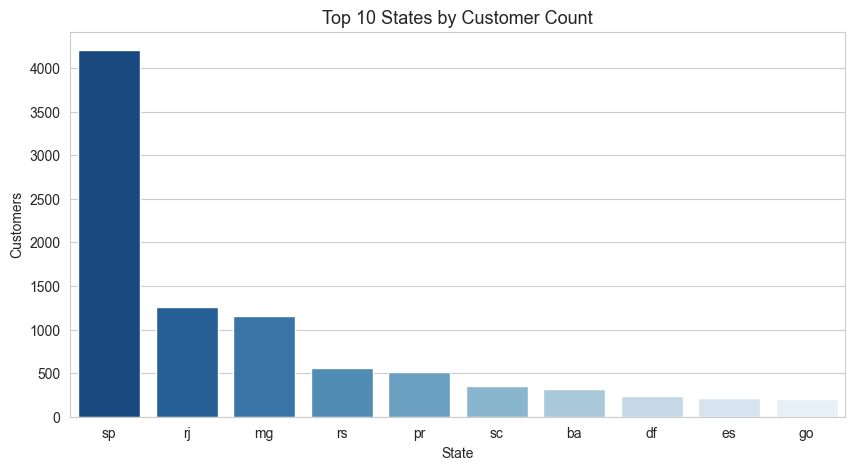

Top 10 cities:
 customer_city
sao paulo                1580
rio de janeiro            670
belo horizonte            261
brasilia                  242
campinas                  149
curitiba                  145
porto alegre              139
guarulhos                 122
salvador                  120
sao bernardo do campo     101
Name: count, dtype: int64


In [214]:
#Top 10 states by customer count
state_counts = order_level["customer_state"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_counts.index, y=state_counts.values, palette="Blues_r")
plt.title("Top 10 States by Customer Count")
plt.xlabel("State"); plt.ylabel("Customers")
plt.show()

#Top 10 cities
city_counts = order_level["customer_city"].value_counts().head(10)
print("Top 10 cities:\n", city_counts)



Order status:
 order_status
delivered      9715
shipped         101
canceled         68
unavailable      61
invoiced         33
Name: count, dtype: int64


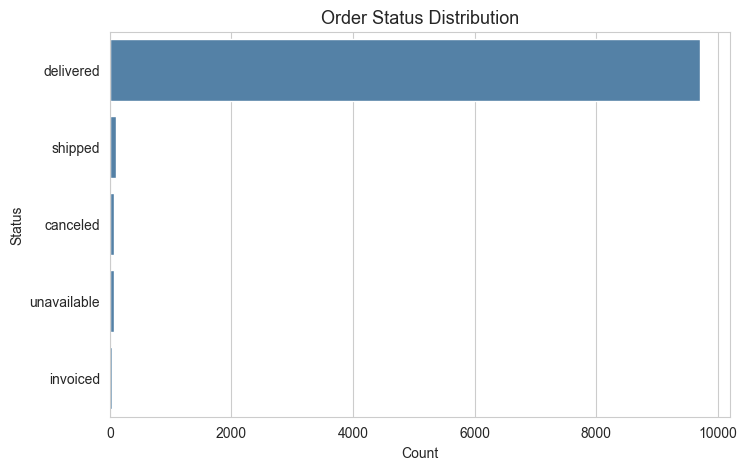

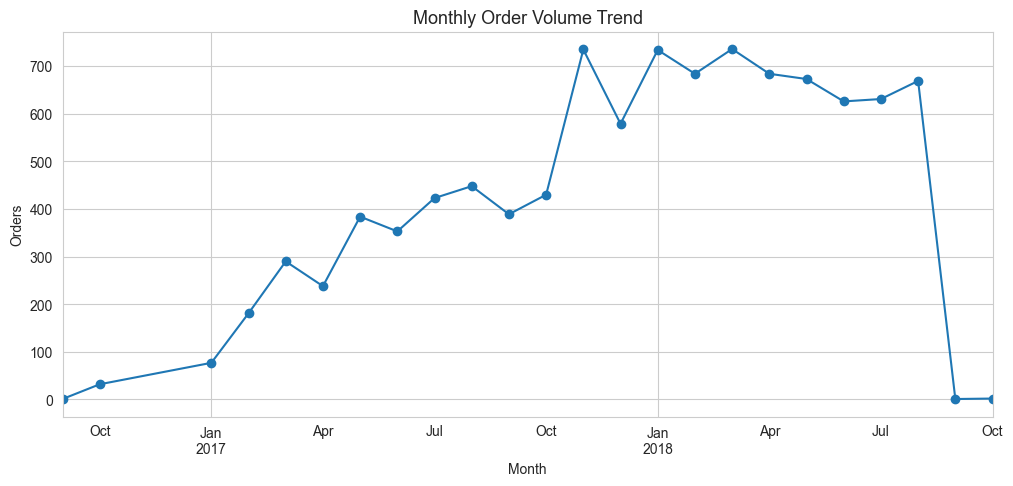

In [215]:
#Order analysis and monthly trend

order_level["order_purchase_timestamp"] = pd.to_datetime(
    order_level["order_purchase_timestamp"], errors="coerce"
)

#Order status distribution
status_counts = order_level["order_status"].value_counts().head()
print("Order status:\n", status_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=status_counts.values, y=status_counts.index, color="steelblue")
plt.title("Order Status Distribution")
plt.xlabel("Count"); plt.ylabel("Status")
plt.show()

#Monthly order value trend
order_level["purchase_month"] = order_level["order_purchase_timestamp"].dt.to_period("M")
monthly = order_level.groupby("purchase_month").size()

plt.figure(figsize=(12,5))
monthly.plot(kind="line", marker="o")
plt.title("Monthly Order Volume Trend")
plt.xlabel("Month"); plt.ylabel("Orders")
plt.grid(True)
plt.show()

#Delivery Perfomance Analysis

#Calculating delivered orders
delivered = order_level[order_level["is_delivered"] == 1].copy()

#Actual delivery days = delivery date-order date
delivered["delivery_days"] = ( delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days

delivered["is_late"] = (delivered["order_delivered_customer_date"] > delivered["order_estimated_delivery_date"]).astype(int)

print(f"Avg delivery time : {delivered['delivery_days'].mean():.1f} days")
print(f"On-time delivery  : {(1 - delivered['is_late'].mean())*100:.1f}%")
print(f"Late deliveries   : {delivered['is_late'].mean()*100:.1f}%")

print("Mean delivery days  :", round(delivered["delivery_days"].mean(), 1))   
print("Median delivery days:", round(delivered["delivery_days"].median(), 1)) 
print("Max (worst order)   :", delivered["delivery_days"].max(), "days")      

plt.figure(figsize=(10,5))
sns.histplot(delivered["delivery_days"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Delivery Times(days)")
plt.xlabel("Delivery Days"); plt.ylabel("Number of Orders")
plt.show()





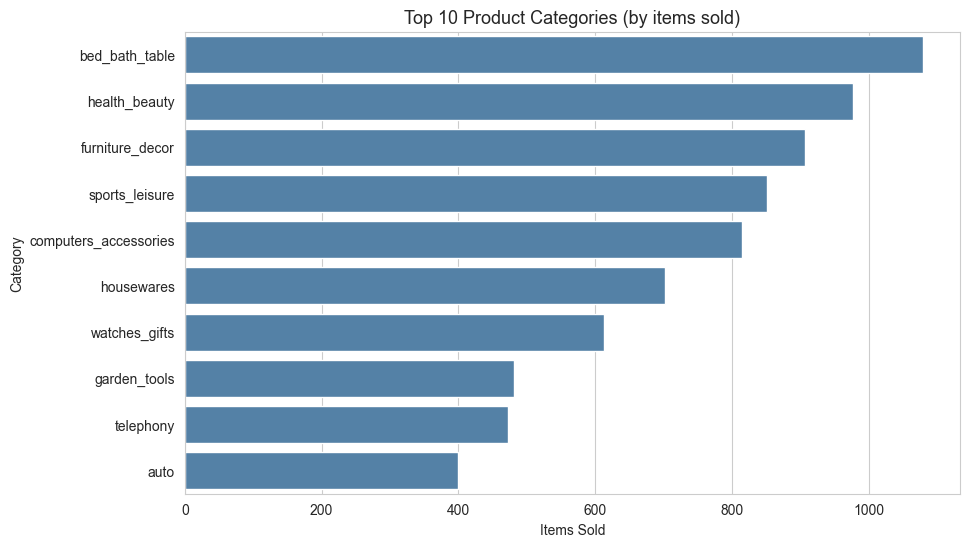

Top categories by revenue:
 product_category_name_english
health_beauty            141728.0
watches_gifts            136689.0
bed_bath_table           122963.0
sports_leisure           117084.0
computers_accessories    106869.0
furniture_decor          100385.0
housewares                77553.0
cool_stuff                66834.0
auto                      62557.0
garden_tools              59548.0
Name: item_revenue, dtype: float64


In [216]:
#Product category analysis

#Top 10 categories by number of items sold
top_cat = item_level["product_category_name_english"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cat.values, y=top_cat.index, color="steelblue")
plt.title("Top 10 Product Categories (by items sold)")
plt.xlabel("Items Sold"); plt.ylabel("Category")
plt.show()


## Top 10 Categories by Revenue
cat_revenue = (
    item_level.groupby("product_category_name_english")["item_revenue"]
    .sum().sort_values(ascending=False).head(10)
)
print("Top categories by revenue:\n", cat_revenue.round(0))                      

Top sellers by Revenue and Region

In [217]:
#Top 10 sellers by Revenue
top_sellers = (
    item_level.groupby("seller_id")["item_revenue"]
    .sum().sort_values(ascending=False).head(10)
)
print("Top 10 sellers by revenue:\n", top_sellers.round(0))


Top 10 sellers by revenue:
 seller_id
4a3ca9315b744ce9f8e9374361493884    24872.0
fa1c13f2614d7b5c4749cbc52fecda94    24119.0
7c67e1448b00f6e969d365cea6b010ab    24110.0
4869f7a5dfa277a7dca6462dcf3b52b2    22650.0
7e93a43ef30c4f03f38b393420bc753a    22320.0
1025f0e2d44d7041d6cf58b6550e0bfa    21088.0
da8622b14eb17ae2831f4ac5b9dab84a    18885.0
6560211a19b47992c3666cc44a7e94c0    16926.0
1f50f920176fa81dab994f9023523100    16280.0
7a67c85e85bb2ce8582c35f2203ad736    16272.0
Name: item_revenue, dtype: float64


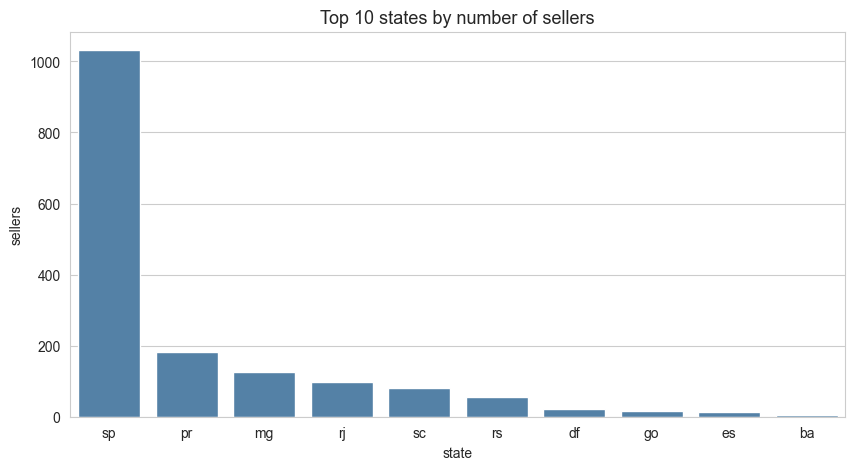

In [218]:
#Seller distribution by state
seller_states = item_level.drop_duplicates("seller_id")["seller_state"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=seller_states.index, y=seller_states.values, color="steelblue")
plt.title("Top 10 states by number of sellers")
plt.xlabel("state"); plt.ylabel("sellers")
plt.show()

In [220]:
#top 20 percent sellers
seller_rev = item_level.groupby("seller_id")["item_revenue"].sum().sort_values(ascending=False)
top20_pct_count = int(len(seller_rev) * 0.20)
contribution = seller_rev.head(top20_pct_count).sum() / seller_rev.sum() * 100
print(f"\nTop 20% sellers contribute {contribution:.1f}% of revenue")


Top 20% sellers contribute 72.2% of revenue


Payment methods:
 main_payment_type
credit_card    7653
boleto         1967
voucher         230
debit_card      149
unknown           1
Name: count, dtype: int64


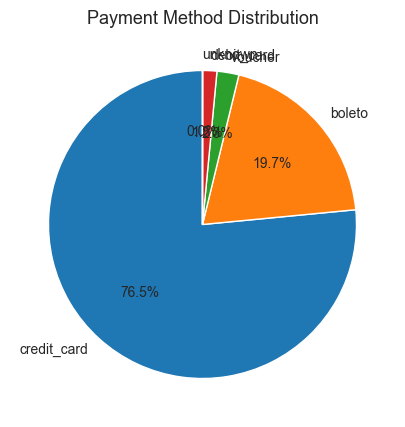

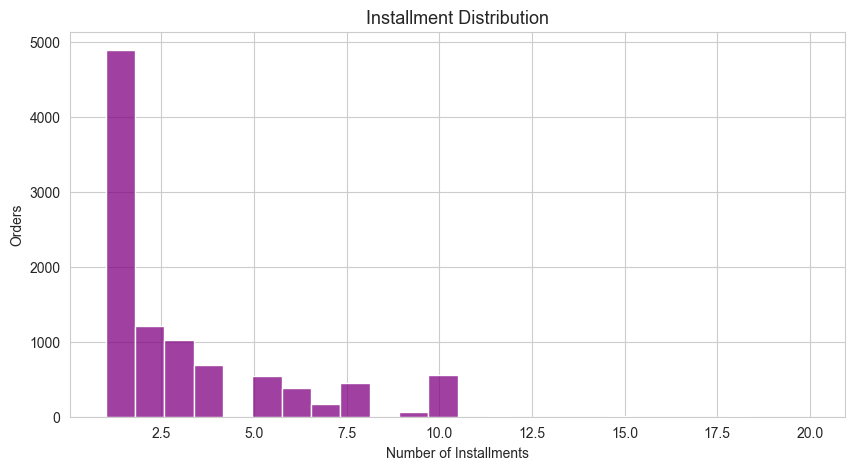


Avg installments: 2.9
Single payment (1): 48.9% of orders


In [221]:
# --- Payment method distribution ---
pay_methods = order_level["main_payment_type"].value_counts()
print("Payment methods:\n", pay_methods)

plt.figure(figsize=(8,5))
plt.pie(pay_methods.values, labels=pay_methods.index, autopct="%1.1f%%", startangle=90)
plt.title("Payment Method Distribution")
plt.show()

# --- Installment distribution ---
plt.figure(figsize=(10,5))
sns.histplot(order_level["max_installments"], bins=24, color="purple")
plt.title("Installment Distribution")
plt.xlabel("Number of Installments"); plt.ylabel("Orders")
plt.show()

print(f"\nAvg installments: {order_level['max_installments'].mean():.1f}")
print(f"Single payment (1): {(order_level['max_installments']==1).mean()*100:.1f}% of orders")